## Setup for EDA and time series 

In [97]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Data Viz. 
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.ndimage import gaussian_filter
from calendar import monthrange
from calendar import month_name

from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf

from pmdarima.arima import auto_arima
import statsmodels.graphics.tsaplots as tsaplot
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing

#New Libraries
#from statsmodels.tsa.statespace.sarimax import SARIMAX
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'
cmaps_hex = ['#193251','#FF5A36','#696969', '#7589A2','#FF5A36', '#DB6668']
sns.set_palette(palette=cmaps_hex)
sns_c = sns.color_palette(palette=cmaps_hex)
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [27]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [28]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [29]:
#res_df.dtypes

In [30]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [31]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [32]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [33]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [34]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [35]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [36]:
data_df_gwh = data_df_mwh.copy()

In [37]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [38]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [39]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [40]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [41]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [42]:

data_df= data_df_gwh.copy()

In [43]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [44]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [45]:
##data_df.columns

In [46]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [47]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files
main_0  = 'Total_energy_generation_gwh' # This is only for energy
#main_0  = 'Solar_gwh' # for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Total energy generation in GWh
Total energy generation(GWh)


### Here we set the function for line plot  

In [48]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



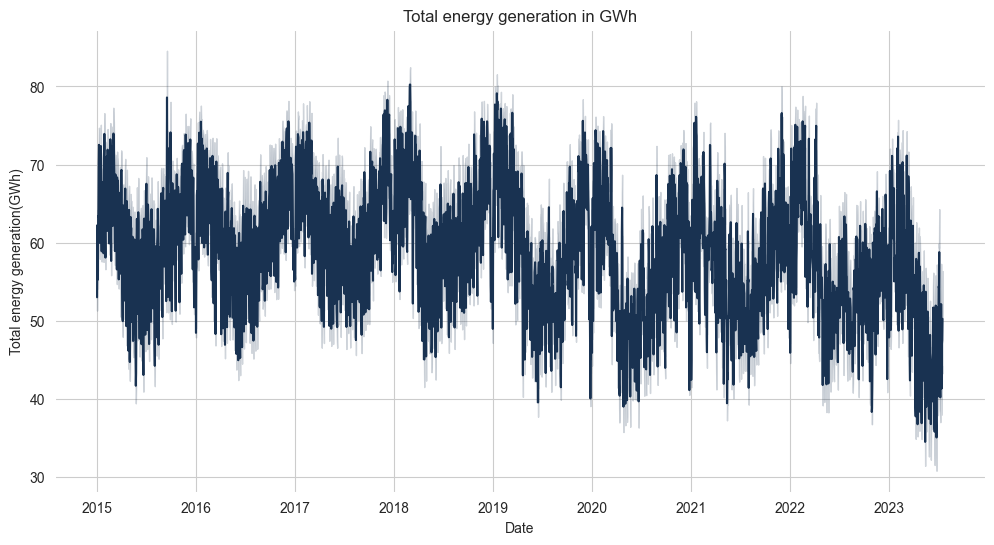

In [49]:
## Energy development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
ax.set(title=title_main, ylabel= ylable_target);

In [50]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [51]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [52]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

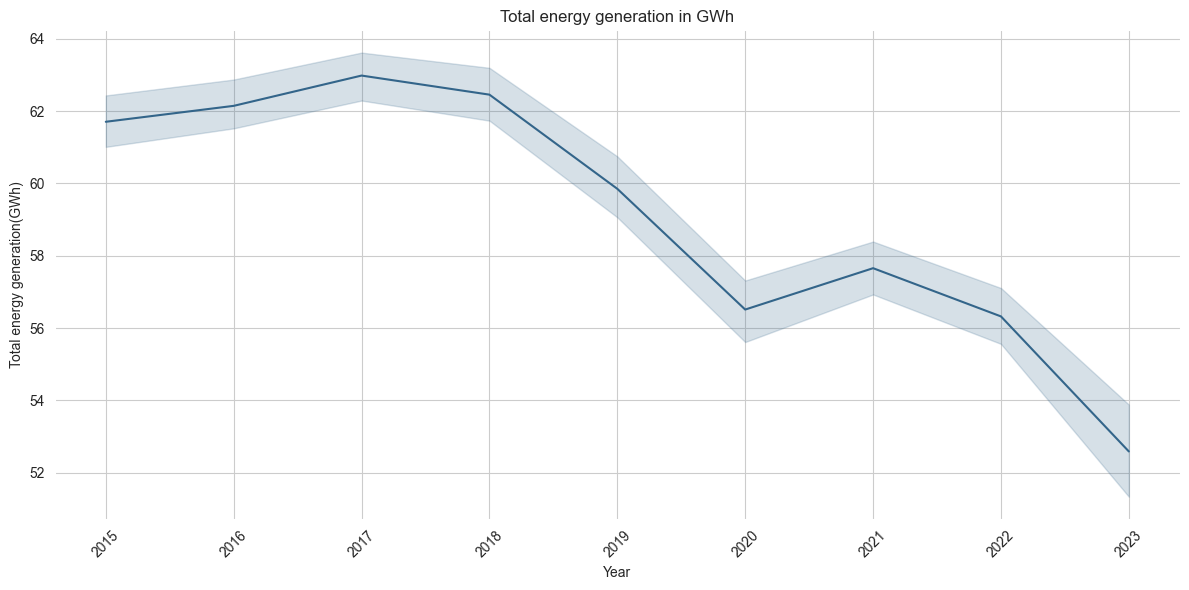

In [53]:
average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [54]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [55]:
daily_data_df

,Year,Month,Day,Dayofyear,Hour,Total_energy_generation_gwh
Date,,,,,,
2015-01-01,2015,1,1,1,0,51.45925
2015-01-01,2015,1,1,1,1,49.98825
2015-01-01,2015,1,1,1,2,49.26525
2015-01-01,2015,1,1,1,3,48.53800
2015-01-01,2015,1,1,1,4,48.63000
...,...,...,...,...,...,...
2023-07-17,2023,7,17,198,18,55.58000
2023-07-17,2023,7,17,198,19,50.83350
2023-07-17,2023,7,17,198,20,46.67225


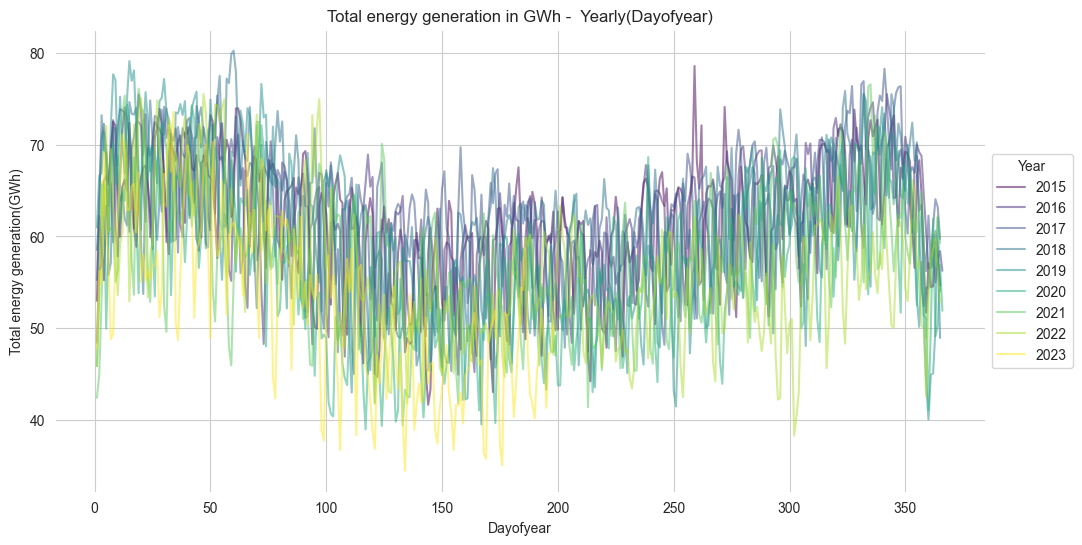

In [59]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [60]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [61]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

### Creating train and test sets
We will split our data and take the first part as our training set and the years after 2016 as a test set. Since we are dealing with a time series here we cannot split randomly as we are used to do. 

([], [])

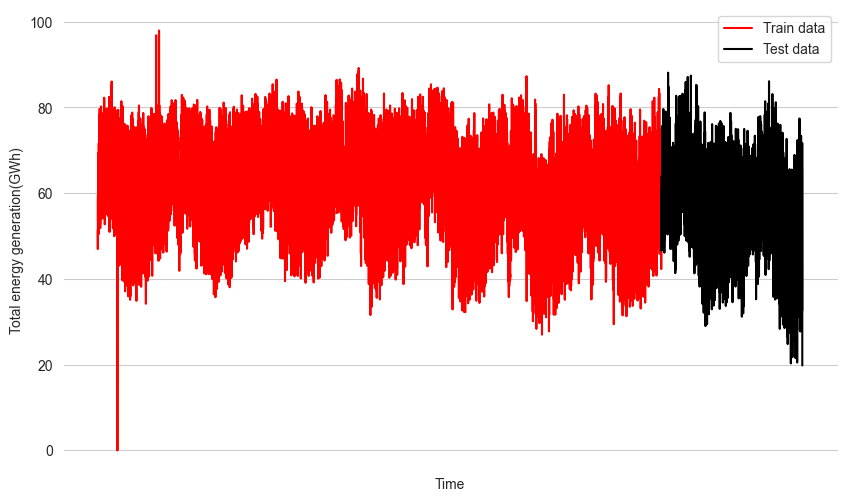

In [63]:
# Split data into train and test set
#window=365#*24
#df_arima = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_arima = df_arima.dropna()
#

df_arima = data_df[target]
train_test_split_ratio = int(len(df_arima)*0.8)
train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]

# Plotting the train and test set
plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.plot(train_data, 'red', label='Train data')
plt.plot(test_data, 'black', label='Test data')
plt.legend()
plt.xticks([])
#plt.xlim(pd.to_datetime("2015"),pd.to_datetime("2023"))

In [64]:
### fitting the model
#model = ARIMA(train['total_energy_generation_'], order=(2,1,2))
#model_fit = model.fit(disp=0)
#print(model_fit.summary())

## Model Building

After splitting the data we can now try to forcast the prices. We can use smoothing methods and ARIMA methods. While smoothing methods can be used for non-stationray data, ARIMA requires the data to be stationary. `auto_arima` can help us to make the series stationary and determine the optimal order for the ARIMA model.

We will perform multiple fits for each model to find the best hyperparamters. 

### Simple Exponential Smoothing

Simple Exponential Smoothing (SES) is used when the data doesn't contain any trend or seasonality. Smoothing Factor for level ($\alpha$) provides weightage to the influence of the observations. With larger values of $\alpha$ more attention is given to the most recent past observations whereas smaller values indicate that more past observations are being considered for forecasting. 

$$F_{t+1} = \alpha d_t + (1 - \alpha)F_t$$

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/

Simple Exponential Smoothing RMS :- 11.328 & Smoothing Level :- 0.05


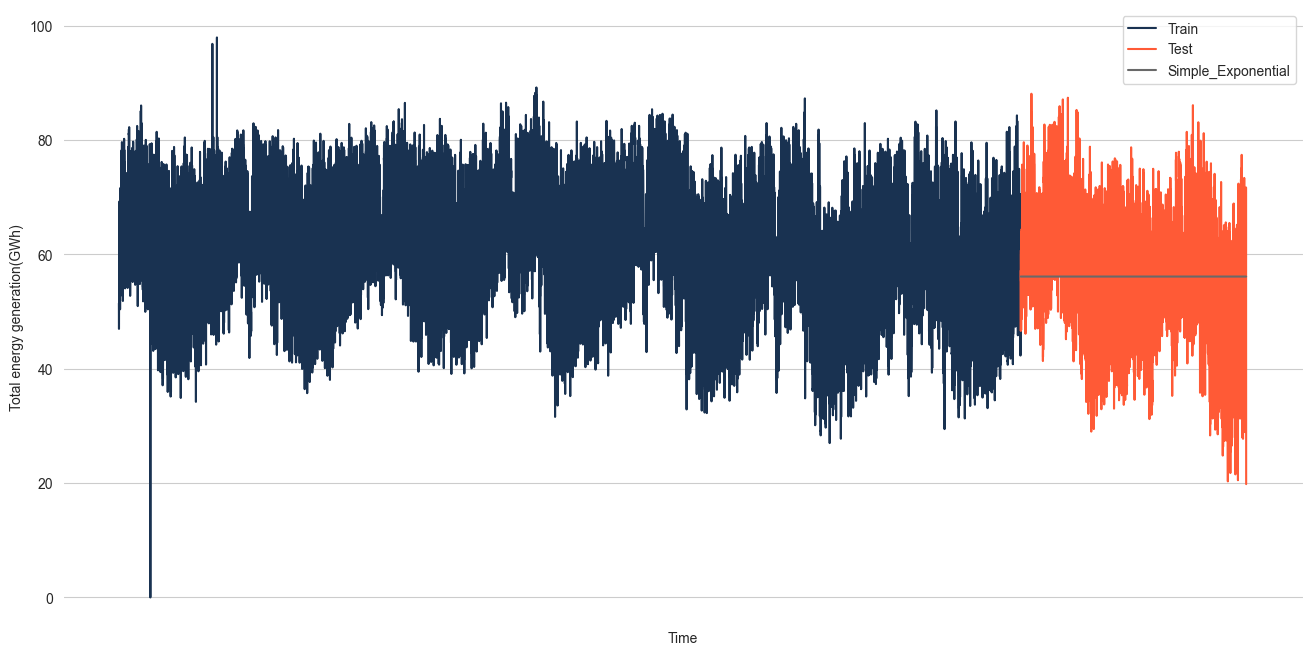

In [65]:
# Simple Exponential Smoothing Method
pred_values = test_data.copy()
pred_values = pd.DataFrame(pred_values)

simple_exponential_df = pd.DataFrame(columns = ['RMS','Smoothing Level'])

from itertools import permutations
perm = permutations(list(np.linspace(0.05,1,num=20)), 1)
for i in list(perm):
    fit_sim_exp = SimpleExpSmoothing(np.asarray(train_data)).fit(smoothing_level = i[0])
    pred_values['Simple_Exponential'] = fit_sim_exp.forecast(len(test_data))

    rms = round(sqrt(mean_squared_error(test_data.values, pred_values.Simple_Exponential)),3)
    simple_exponential_df = pd.concat([simple_exponential_df, pd.DataFrame({'RMS' : [rms] , 'Smoothing Level' : [i[0]]})], ignore_index=True)

opt_values = simple_exponential_df.loc[simple_exponential_df['RMS'] == min(simple_exponential_df['RMS']),['Smoothing Level']].values


# Use optimised values from the lists
fit_sim_exp = SimpleExpSmoothing(np.asarray(train_data)).fit(smoothing_level = opt_values[0][0])
pred_values['Simple_Exponential'] = fit_sim_exp.forecast(len(test_data))

plt.figure(figsize=(16,8))
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(pred_values['Simple_Exponential'], label='Simple_Exponential')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='best')

rms_sim_exp = sqrt(mean_squared_error(test_data.values, pred_values.Simple_Exponential))
print("Simple Exponential Smoothing RMS :- " + str(round(rms_sim_exp,3)) + " & Smoothing Level :- "+str(round(opt_values[0][0],3)))

#plt.savefig("visualisations/Energy_Simple_Exponential.png",dpi=300)

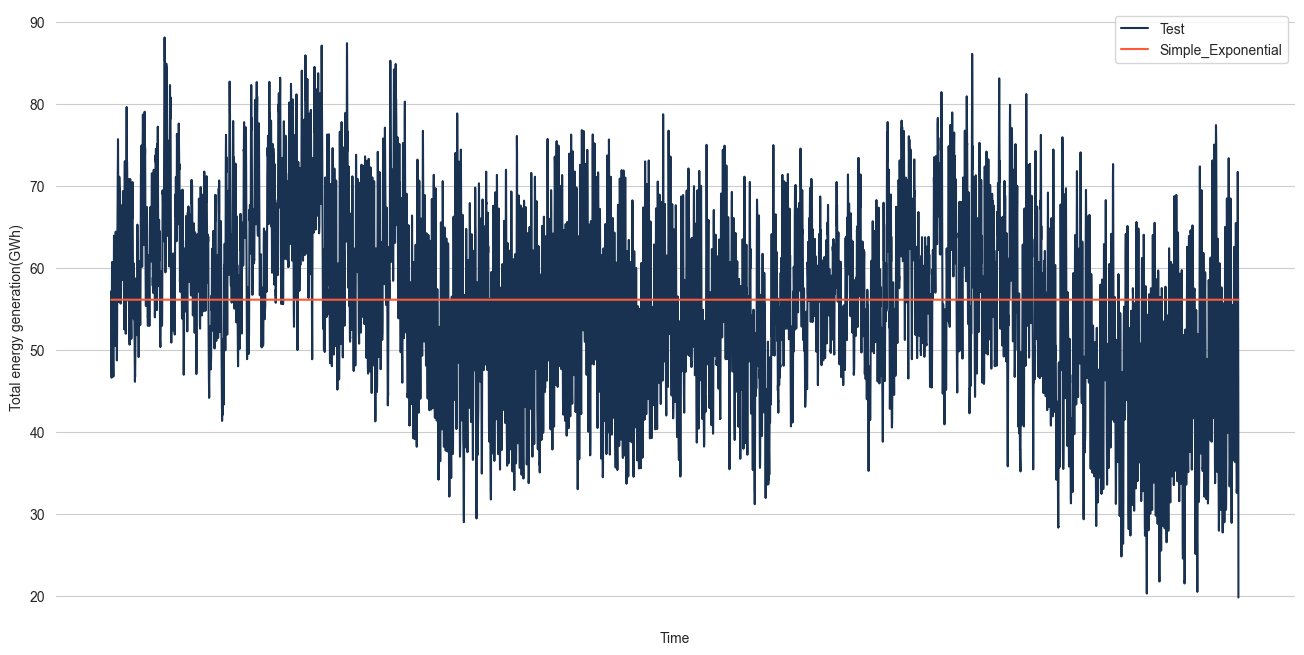

In [66]:
# Simple Exponential Smoothing Method
plt.figure(figsize=(16,8))
#plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(pred_values['Simple_Exponential'], label='Simple_Exponential')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='best')

#plt.savefig("visualisations/Energy_Simple_Exponential.png",dpi=300)

### Holt's Exponential Smoothing

Holt’s Exponential Smoothing takes the trend into account for forecasting the time series. We can use it when we have a trend but no seasonality in the data. It calculates the Smoothing value, which is the same used in SES for forecasting (first equation). Trend Coefficient (β) provides weightage to the difference in the consequent smoothing values and the previous trend estimate. The forecasting is a combination of the smoothing value and the trend estimate.

$$S_t = \alpha d_t + (1 - \alpha)F_t$$
$$b_t = \beta (S_t - S_{t-1}) + (1 - \beta) b_{t-1}$$
$$F_{t+1} = S_t + b_t$$

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_59031/2130103322.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fit_holt = Holt(np.asarray(train_data)).fit(smoothing_level = i[0],smoothing_slope=i[1])
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_59031/2130103322.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fit_holt = Holt(np.asarray(train_data)).fit(smoothing_level = i[0],smoothing_slope=i[1])
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: Estimat

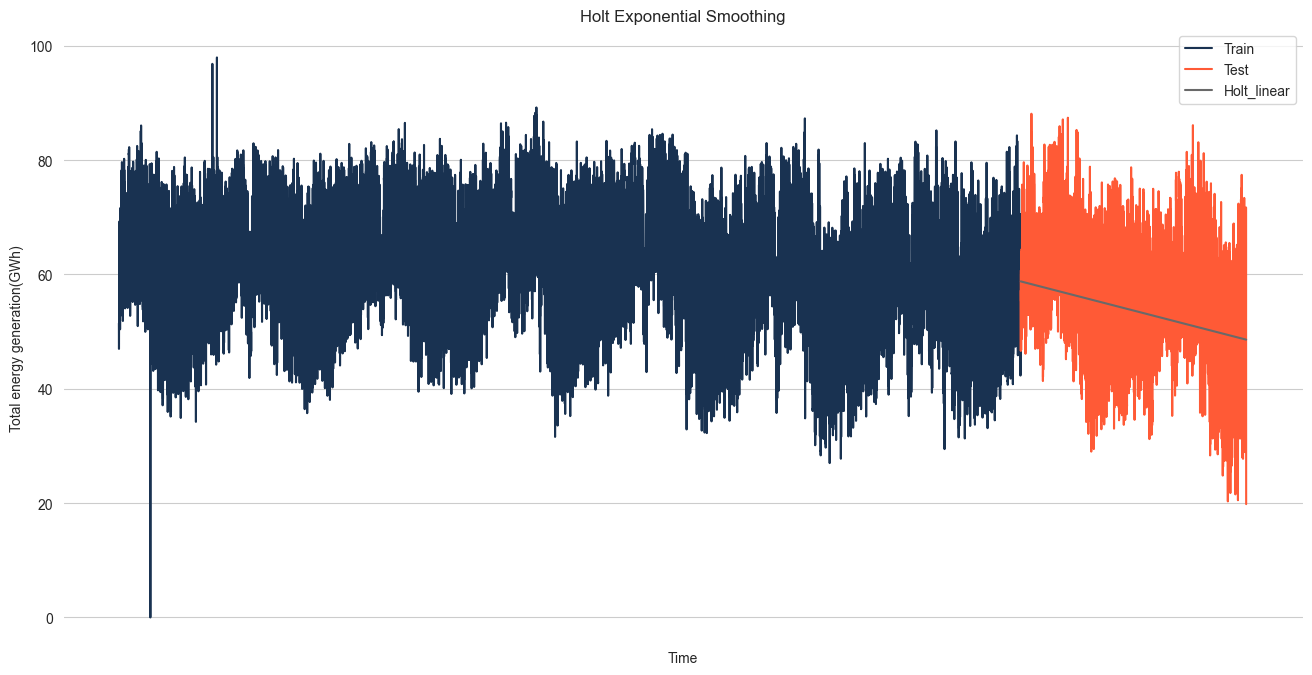

In [67]:
# Holt's Exponential Smoothing Method
holt_linear_df = pd.DataFrame(columns = ['RMS','Smoothing Level','Smoothing Slope'])

perm = permutations(list(np.linspace(0.05,1,num=20)), 2)
for i in list(perm):
    fit_holt = Holt(np.asarray(train_data)).fit(smoothing_level = i[0],smoothing_slope=i[1])
    pred_values['Holt_linear'] = fit_holt.forecast(len(test_data))

    rms = round(sqrt(mean_squared_error(test_data.values, pred_values.Holt_linear)),3)
    #holt_linear_df = holt_linear_df.append(other = {'RMS' : rms , 'Smoothing Level' : i[0], 'Smoothing Slope':i[1]} , ignore_index=True)
    holt_linear_df = pd.concat([holt_linear_df, pd.DataFrame({'RMS' : [rms] , 'Smoothing Level' : [i[0]], 'Smoothing Slope':[i[1]]})], ignore_index=True)

opt_values = holt_linear_df.loc[holt_linear_df['RMS'] == min(holt_linear_df['RMS']),['Smoothing Level','Smoothing Slope']].values


# Using optimised values from the lists.
fit_holt = Holt(np.asarray(train_data)).fit(smoothing_level = opt_values[0][0],smoothing_slope=opt_values[0][1])
pred_values['Holt_linear'] = fit_holt.forecast(len(test_data))

plt.figure(figsize=(16,8))
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(pred_values['Holt_linear'], label='Holt_linear')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='best')
plt.title('Holt Exponential Smoothing')
#plt.savefig("visualisations/Stock_Holt_winters.png",dpi=300)
rms_holt_exp = sqrt(mean_squared_error(test_data.values, pred_values.Holt_linear))
#print("Holt’s Exponential Smoothing RMS :- " + str(round(rms_holt_exp,3)) + " & Smoothing Level :- "+str(round(opt_values[0][0],3)) + " & Smoothing Slope :- "+str(round(opt_values[0][1],3)))


Text(0.5, 1.0, 'Holt Exponential Smoothing')

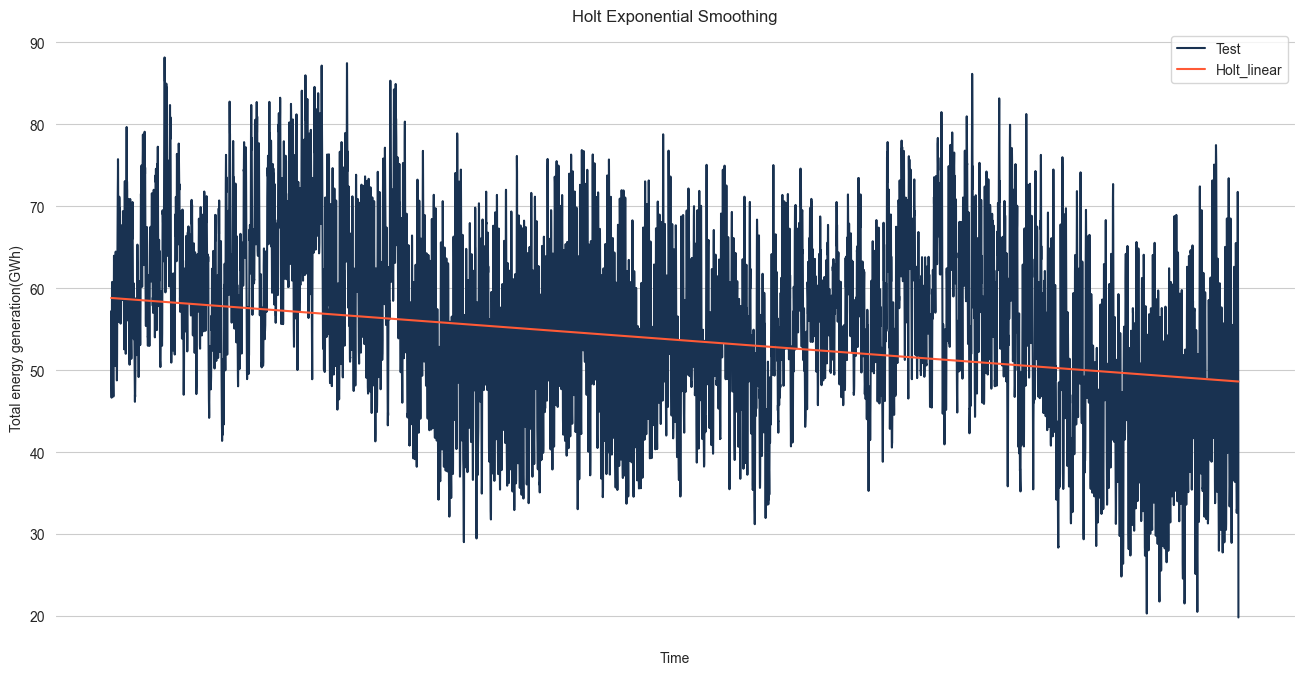

In [111]:
# Holt's Exponential Smoothing Method
plt.figure(figsize=(16,8))
#plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(pred_values['Holt_linear'], label='Holt_linear')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='best')
plt.title('Holt Exponential Smoothing')
#plt.savefig("visualisations/Stock_Holt_winters.png",dpi=300)


### Auto-Regressive Integrated Moving Average (ARIMA)

ARIMA model is a combination of Auto-Regressive and Moving Average model along with the Integration of differencing. Auto-Regressive model determines the relationship between an observation and a certain number of lagged observations. The Integrated part is the differencing of the actual observations to make the time series stationary. Moving Average determines the relationship between an observation and residual error obtained by using a moving average model on the lagged observations.

* *Auto-Regressive (p)*: Number of lag observations in the model. Also called lag order.
* *Integrated (d)*: Number of times the actual observations are differenced for stationarity. Also called degree of differencing.
* *Moving Average (q)*: Size of moving average window. Also called the order of moving average.

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=239756.015, Time=1.26 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=663222.517, Time=0.20 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.33 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=581607.169, Time=1.60 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=220958.151, Time=1.28 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.69 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=8.60 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=220499.340, Time=1.86 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=227396.177, Time=1.48 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=213269.635, Time=8.41 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=221210.502, Time=9.54 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=220476.796, Time=12.52 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=220406.608, Time=2.67 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=220789.113, Time=11.00 sec
 ARIMA(4,0,3)(0,0,0)[0] 

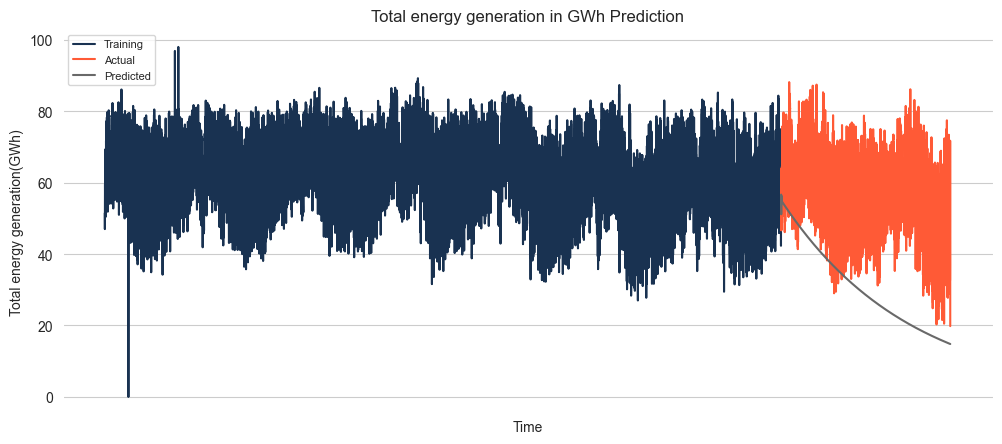

In [69]:
# Auto ARIMA Method
arima_model = auto_arima(train_data,
                      start_p=1, start_q=1,
                      max_p=5, max_q=5,
                      test='adf',        
                      trace=True,
                      alpha=0.05,
                      scoring='mse',
                      suppress_warnings=True,
                      seasonal = False
                      )

# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.05) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))

#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                59903
Model:               SARIMAX(5, 1, 1)   Log Likelihood             -106338.570
Date:                Tue, 25 Jul 2023   AIC                         212691.140
Time:                        19:44:21   BIC                         212754.144
Sample:                             0   HQIC                        212710.711
                              - 59903                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6203      0.002    700.032      0.000       1.616       1.625
ar.L2         -0.6683      0.002   -390.986      0.000      -0.672      -0.665
ar.L3         -0.0455      0.004    -12.116      0.0

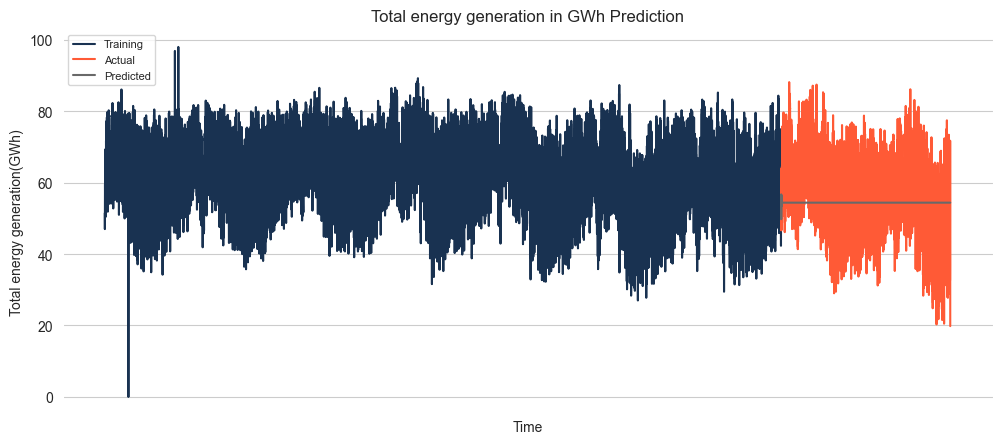

In [87]:
# parameter tuning for varous parameters


# Auto ARIMA Method
arima_model = auto_arima(train_data,
                      start_p=2, start_q=1,
                      max_p=5, max_q=5,
                      test='kpss',        
                      trace=False,
                      alpha=0.05,
                      scoring='mse',
                      suppress_warnings=True,
                      seasonal = True
                      )

# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.05) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))

#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)


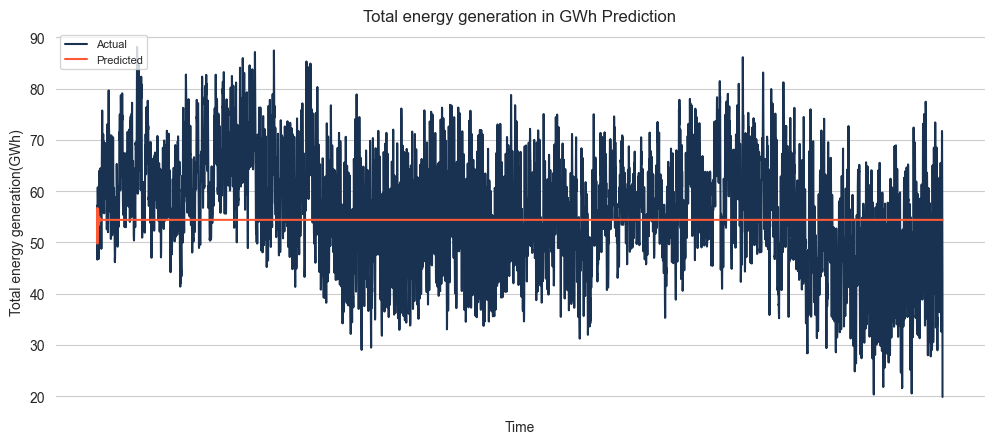

In [91]:
# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
#plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                59903
Model:               SARIMAX(5, 1, 1)   Log Likelihood             -106338.570
Date:                Tue, 25 Jul 2023   AIC                         212691.140
Time:                        20:02:02   BIC                         212754.144
Sample:                             0   HQIC                        212710.711
                              - 59903                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6203      0.002    700.032      0.000       1.616       1.625
ar.L2         -0.6683      0.002   -390.986      0.000      -0.672      -0.665
ar.L3         -0.0455      0.004    -12.116      0.0

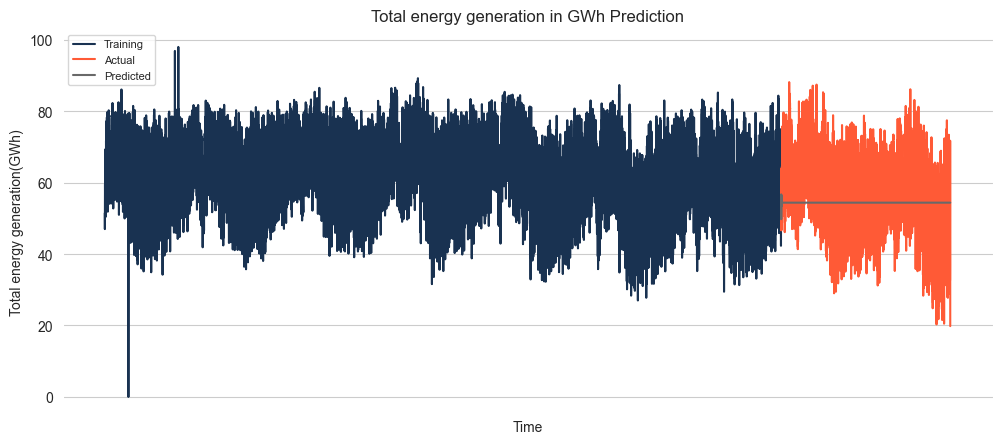

In [89]:
# parameter tuning for varous parameters


# Auto ARIMA Method
arima_model_0 = auto_arima(train_data,
                      start_p=2, start_q=1,
                      max_p=5, max_q=5,
                      test='kpss',        
                      trace=False,
                      alpha=0.05,
                      scoring='mse',
                      suppress_warnings=True,
                      seasonal = True
                      )

# Fit the final model with the order
fitted_model_0 = arima_model_0.fit(train_data) 
print(fitted_model_0.summary())

# Forecasting values
forecast_values_0 = fitted_model_0.predict(len(test_data), alpha=0.005) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series_0 = forecast_values_0

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series_0,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series_0))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))

#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

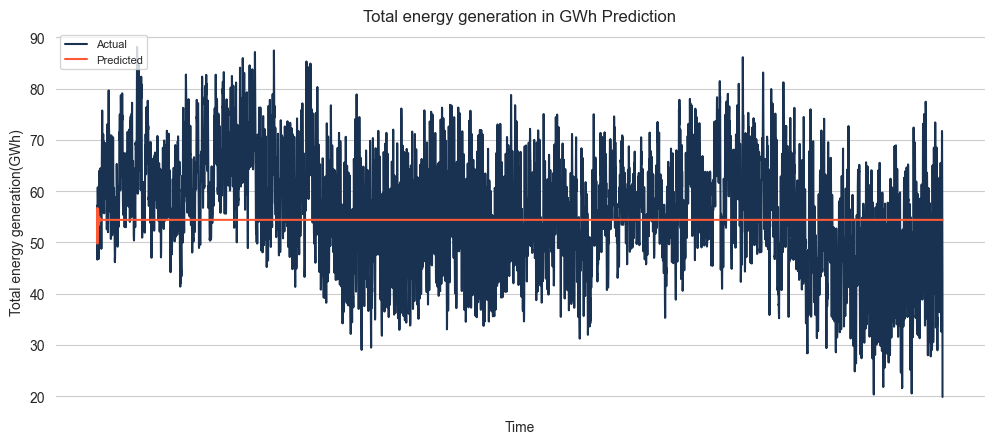

In [90]:
# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
#plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series_0,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                59903
Model:               SARIMAX(5, 1, 1)   Log Likelihood             -106338.570
Date:                Tue, 25 Jul 2023   AIC                         212691.140
Time:                        19:53:15   BIC                         212754.144
Sample:                             0   HQIC                        212710.711
                              - 59903                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6203      0.002    700.032      0.000       1.616       1.625
ar.L2         -0.6683      0.002   -390.986      0.000      -0.672      -0.665
ar.L3         -0.0455      0.004    -12.116      0.0

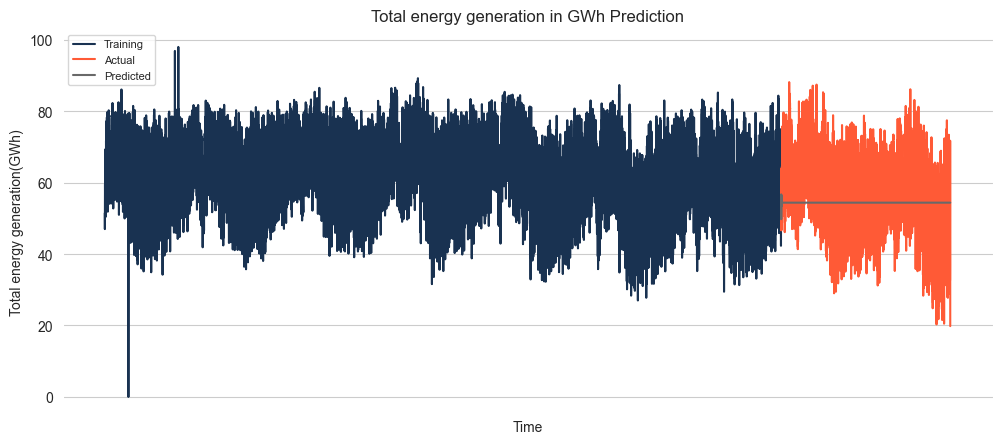

In [88]:
# parameter tuning for varous parameters_n


# Auto ARIMA Method
arima_model_n = auto_arima(train_data)

# Fit the final model with the order
fitted_model_n = arima_model_n.fit(train_data) 
print(fitted_model_n.summary())

# Forecasting values
forecast_values_n = fitted_model_n.predict(len(test_data), alpha=0.1) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series_n = forecast_values_n

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series_n,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series_n))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))

#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

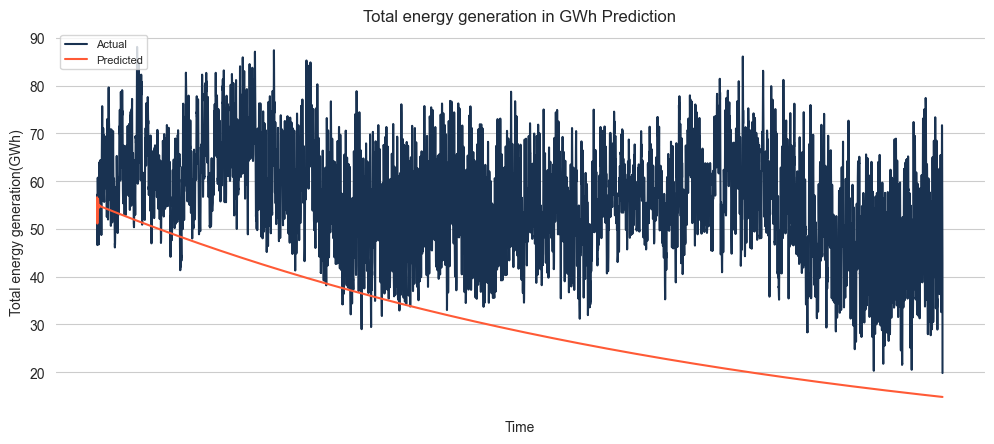

In [70]:
# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
#plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)

## Evaluation of the Models

To evaluate the performance of the model, we will use Root Mean Squared Error (RMSE) and compare which model performed the best.

In [71]:
# Printing RMSE of all the methods
print("RMSE of all the methods")
print("Auto-Arima: ", round(rms_auto_arima,3))
print("Simple Exponential Smoothing: ", round(rms_sim_exp,3))
print("Holt’s Exponential Smoothing: ", round(rms_holt_exp,3))

RMSE of all the methods
Auto-Arima:  28.211
Simple Exponential Smoothing:  11.328
Holt’s Exponential Smoothing:  10.848


In [72]:
#Output from mwh units

#RMSE of all the methods
#Auto-Arima:  12500.19
#Simple Exponential Smoothing:  11414.213
#Holt’s Exponential Smoothing:  10950.264

# New approach

##### split the data into train and test set using .....


In [73]:
df_arima_tstn = data_df[target]
test_percent = 0.15
test_number = int(df_arima_tstn.shape[0]*test_percent)
train_s = df_arima_tstn[:-test_number]
test_s = df_arima_tstn[-test_number:]

train_s.shape, test_s.shape



((63648,), (11231,))

In [74]:
#from statsmodels.tsa.statespace.sarimax import SARIMAX
#from sklearn.metrics import mean_squared_error
#from math import sqrt

#### ARIMA MODEL

In [75]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_s = SARIMAX(train_s, order=(6,1,6), 
                enforce_stationarity=False, 
                enforce_invertibility=False,
                trend="t") # order of _ for AR, 1 differentiation, and _ for MA
model_fit_s = model_s.fit(maxiter=2000)

print('Coefficients: %s' % model_fit_s.params)

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           14     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.85109D+00    |proj g|=  7.12576D+03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   14      1     18      1     0     0   7.126D+03   1.851D+00
  F =   1.8510870127493348     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             



   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.


Coefficients: drift     4.563747e-09
ar.L1     3.433134e-01
ar.L2     4.567965e-01
ar.L3     7.931571e-02
ar.L4     1.611438e-01
ar.L5     4.603376e-01
ar.L6    -6.792296e-01
ma.L1     2.790829e-01
ma.L2    -2.980007e-01
ma.L3    -3.810818e-01
ma.L4    -4.749213e-01
ma.L5    -8.317725e-01
ma.L6    -3.024901e-03
sigma2    1.882430e+00
dtype: float64


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


RMSE:  20.716424507681804


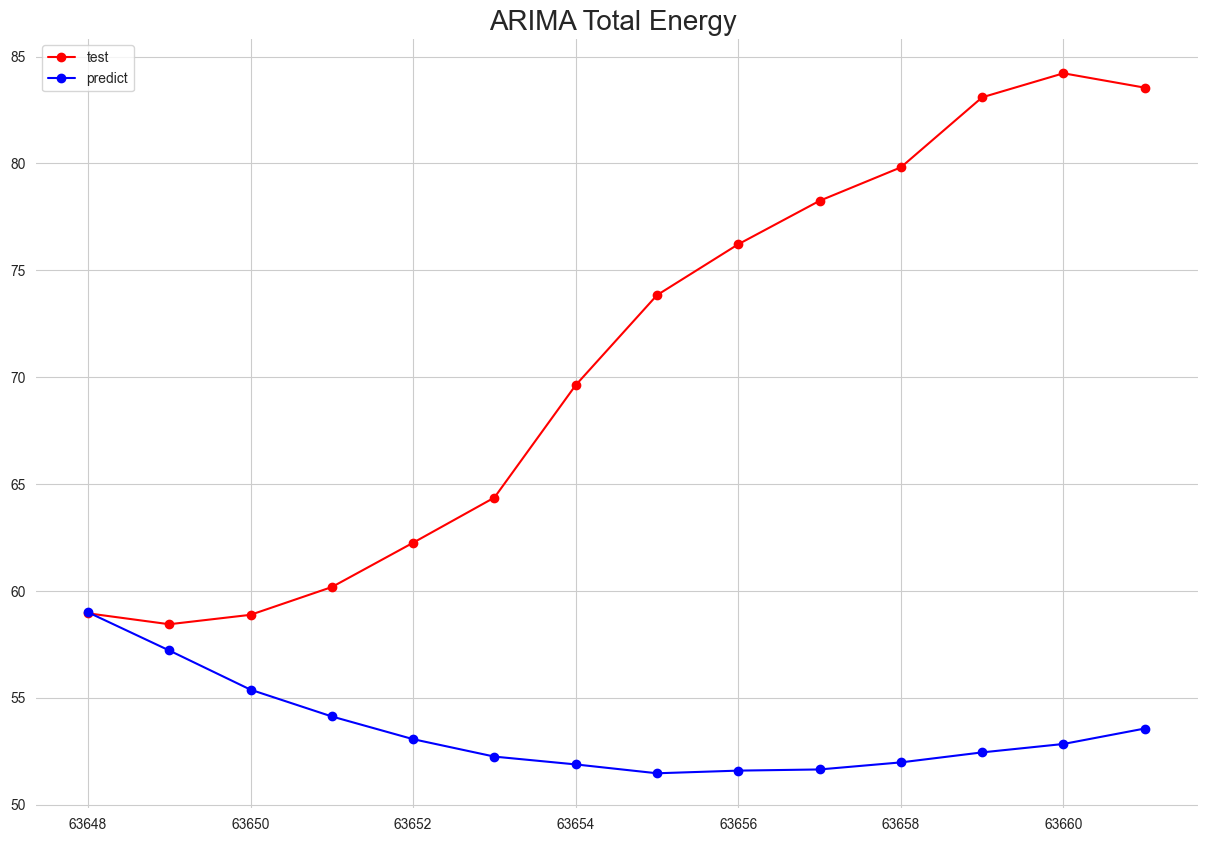

In [76]:
#from sklearn.metrics import mean_squared_error
#from math import sqrt

predictions = model_fit_s.predict(start=len(train_s), end=len(train_s)+len(test_s)-1, typ="levels", index= test_s.index)

print("RMSE: ", sqrt(mean_squared_error(test_s[:14], predictions[:14])))
plt.figure(figsize=(15,10))
plt.plot(test_s[:14], c="red", label="test", marker='o')
plt.plot(predictions[:14], c="blue", label="predict", marker='o')
plt.legend()
plt.title('ARIMA Total Energy ', fontsize=(20))
plt.show();

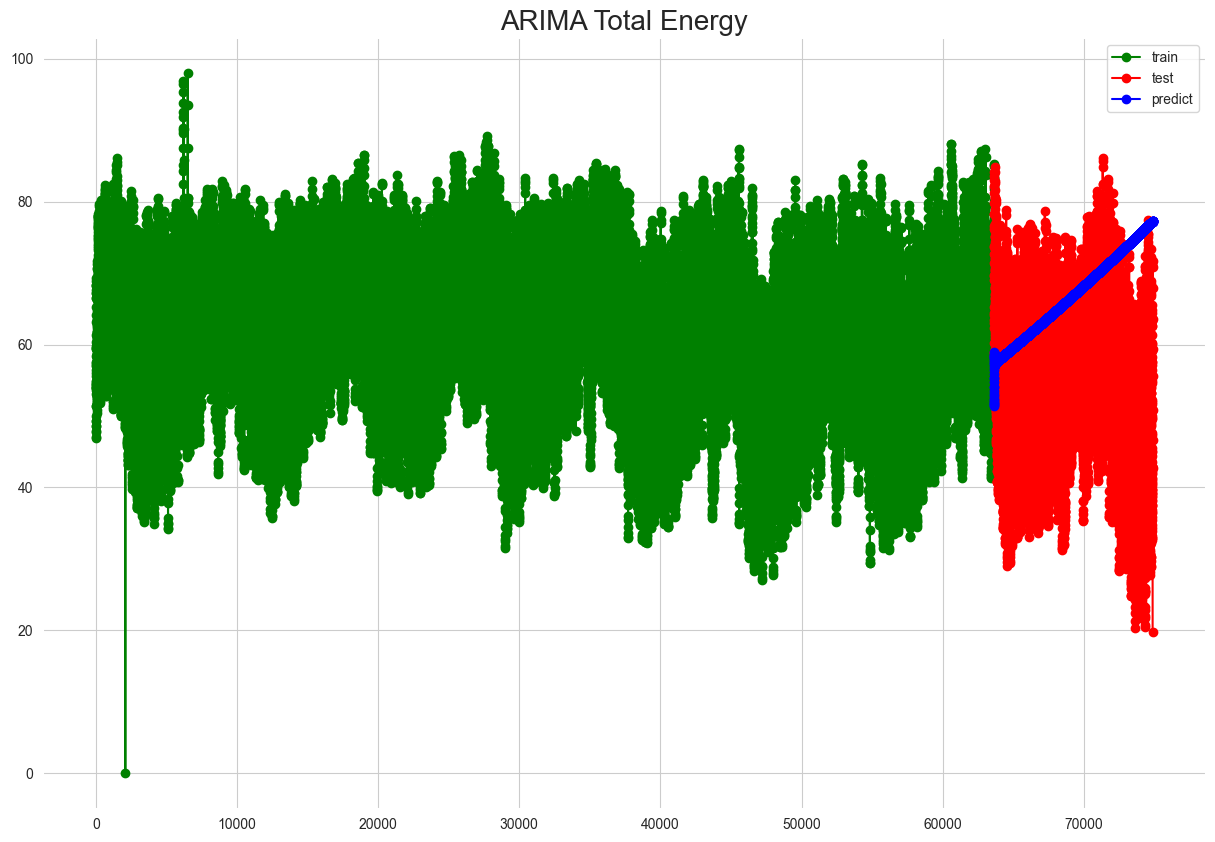

In [77]:
plt.figure(figsize=(15,10))
plt.plot(train_s, c="green", label="train", marker='o')
plt.plot(test_s, c="red", label="test", marker='o')
plt.plot(predictions, c="blue", label="predict", marker='o')
plt.legend()
plt.title('ARIMA Total Energy', fontsize=(20))
plt.show();

#### This is check the mean absolute error

In [78]:
from sklearn.metrics import mean_absolute_error
print("MAE: ", mean_absolute_error(test_s[:14], predictions[:14]))

MAE:  17.379942660795518


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


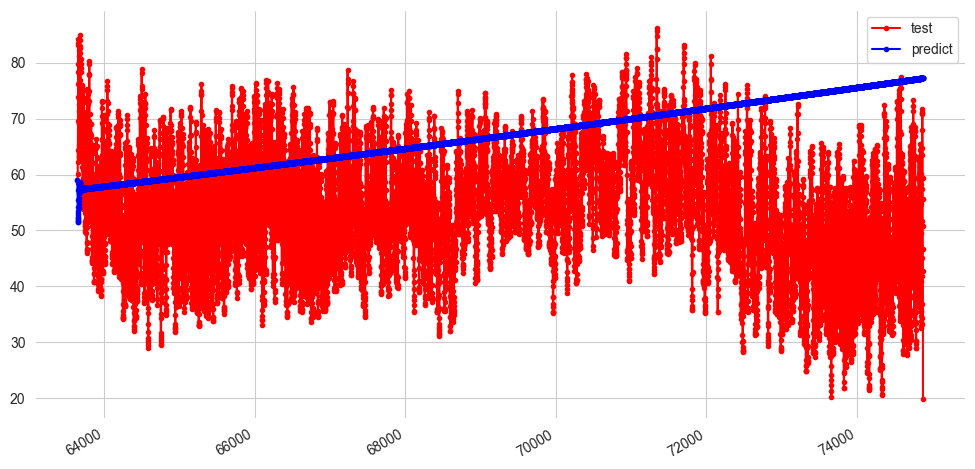

In [79]:
# make prediction
predictions = model_fit_s.predict(start=len(train_s), end=len(train_s)+len(test_s)-1, typ="levels", index=test_s.index)

fig = plt.figure()
plt.plot(test_s, c="red", label="test", marker='.')
plt.plot(predictions, c="blue", label="predict", marker='.')
plt.legend()
fig.autofmt_xdate()
plt.show();

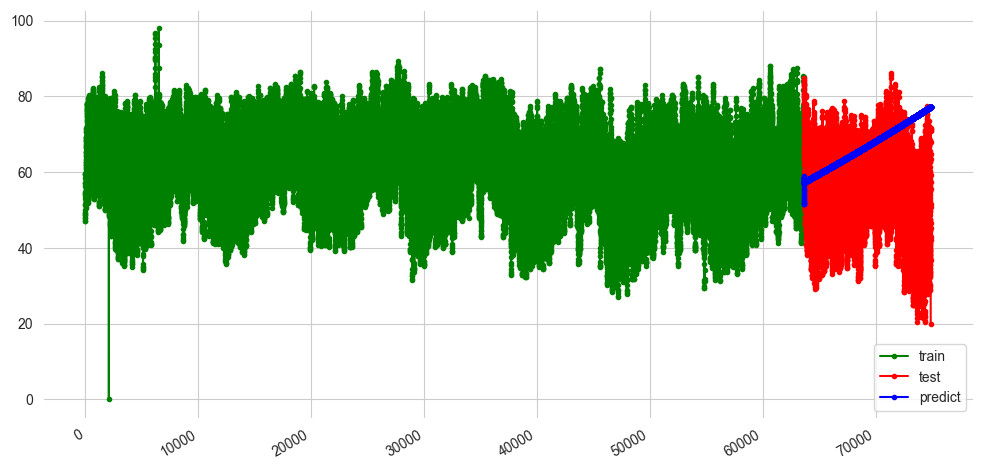

In [80]:

fig = plt.figure()
plt.plot(train_s, c="green", label="train", marker='.')
plt.plot(test_s, c="red", label="test", marker='.')
plt.plot(predictions, c="blue", label="predict", marker='.')
plt.legend()
fig.autofmt_xdate()
plt.show();

In [81]:
#%pip install fbprophet
#%pip installProphet
#from fbprophet import Prophet

In [82]:
# what prophet does
# y(t) = T(t) + S(t) + H(t)

In [83]:
# set up data for prohpet 
dfs = data_df[['Date',  target]]
dfs_d = data_df[target]
x = 'Date'
y = target
dfs

,Date,Total_energy_generation_gwh
0,2015-01-01,51.45925
1,2015-01-01,49.98825
2,2015-01-01,49.26525
3,2015-01-01,48.53800
4,2015-01-01,48.63000
...,...,...
74874,2023-07-17,55.58000
74875,2023-07-17,50.83350
74876,2023-07-17,46.67225
74877,2023-07-17,42.74150


(74879, 2)


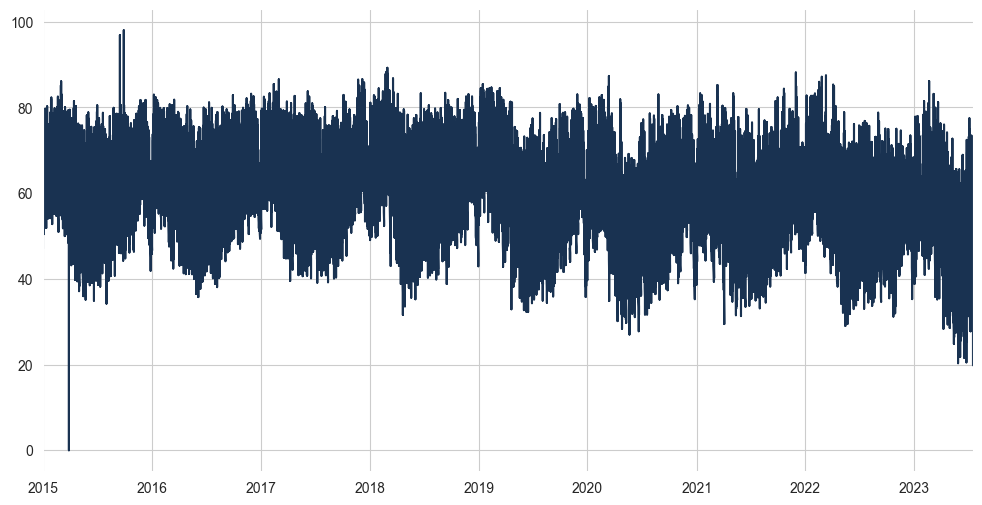

In [84]:
print(dfs.shape)
plt.figure()
plt.plot(dfs['Date'], dfs[target])
plt.autoscale(enable=True, axis='x', tight=True)
plt.show();

In [15]:
#dfs[x].dt.year

In [125]:
# Split the data up
#train = dfs.loc[dfs[x].dt.year < 2022,:]
#test = dfs.loc[dfs[x].dt.year >= 2022, :]
#test_number = 274
#print(train.shape, test.shape)

#plt.figure(figsize=(15,5))
#plt.plot(train[x],train[y].values, c="blue", label="train")
#plt.plot(test[x], test[y].values, c="red", label="test")
#plt.autoscale(enable=True, axis=x, tight=True)
#plt.legend()
#plt.show();

(61369, 2) (13510, 2)


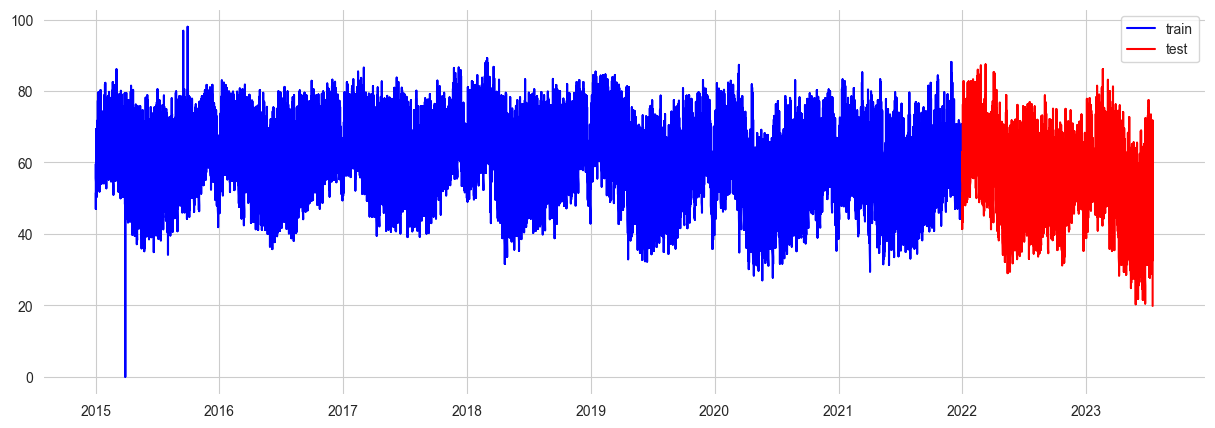

## Test train  data split

In [92]:
df_arima_0 = dfs[target]
train_test_split_ratio_0 = int(len(df_arima_0)*0.8)
train_data_0, test_data_0 = df_arima_0[:train_test_split_ratio_0], df_arima_0[train_test_split_ratio_0:]


## auto_arima fit

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                59903
Model:               SARIMAX(5, 1, 1)   Log Likelihood             -106338.570
Date:                Tue, 25 Jul 2023   AIC                         212691.140
Time:                        20:53:15   BIC                         212754.144
Sample:                             0   HQIC                        212710.711
                              - 59903                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6203      0.002    700.032      0.000       1.616       1.625
ar.L2         -0.6683      0.002   -390.986      0.000      -0.672      -0.665
ar.L3         -0.0455      0.004    -12.116      0.0

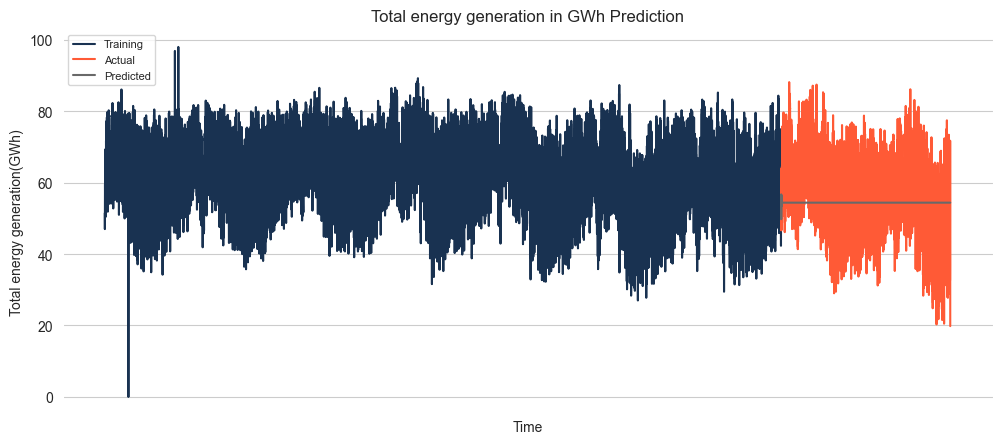

In [93]:
# Auto ARIMA Method
arima_model_0 = auto_arima(train_data_0)

# Fit the final model with the order
fitted_model_0 = arima_model_0.fit(train_data_0) 
print(fitted_model_0.summary())

# Forecasting values
forecast_values_0 = fitted_model_0.predict(len(test_data_0), alpha=0.1) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series_0 = forecast_values_0

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data_0, label='Training')
plt.plot(test_data_0, label='Actual')
plt.plot(fcv_series_0,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data_0.values, fcv_series_0))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))

#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

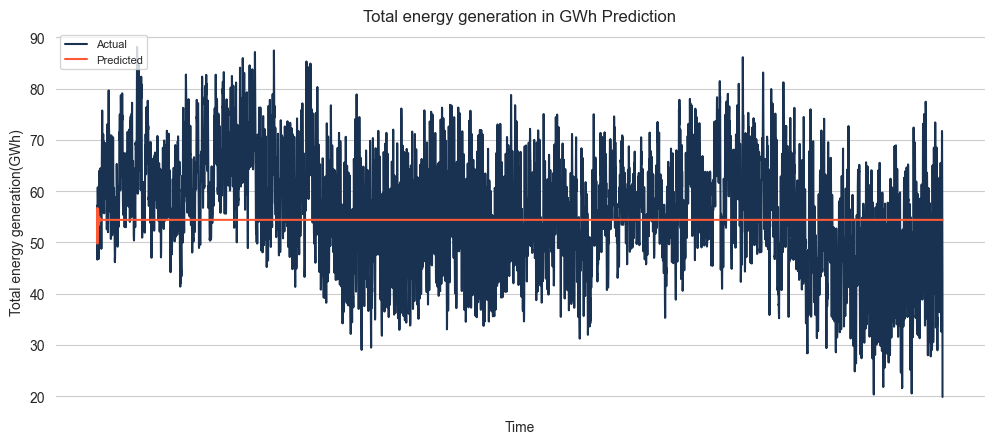

In [94]:
# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
#plt.plot(train_data_0, label='Training')
plt.plot(test_data_0, label='Actual')
plt.plot(fcv_series_0,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                59903
Model:               SARIMAX(5, 1, 1)   Log Likelihood             -106338.570
Date:                Tue, 25 Jul 2023   AIC                         212691.140
Time:                        22:47:00   BIC                         212754.144
Sample:                             0   HQIC                        212710.711
                              - 59903                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6203      0.002    700.032      0.000       1.616       1.625
ar.L2         -0.6683      0.002   -390.986      0.000      -0.672      -0.665
ar.L3         -0.0455      0.004    -12.116      0.0

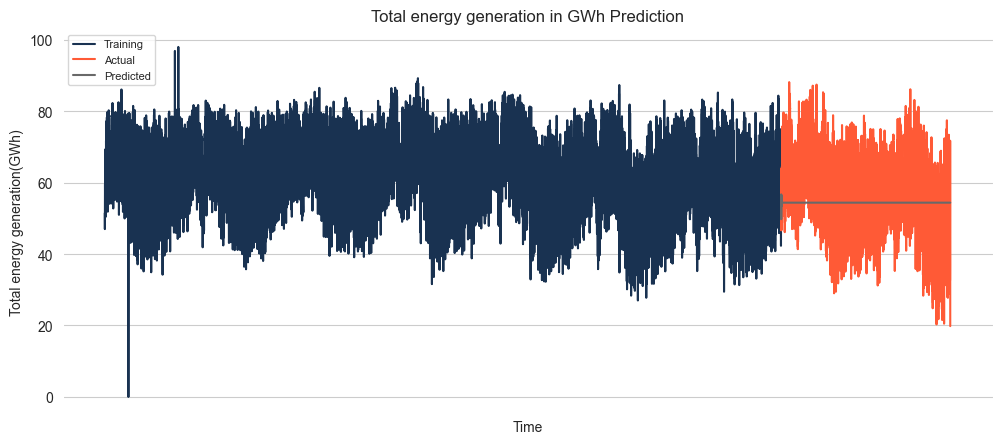

In [110]:
# ARIMA Method
arima_model_a = auto_arima(train_data_0)

# Fit the final model with the order
fitted_model_a = arima_model_0.fit(train_data_0, seasonal=False, stationary=False, test='kpss', stepwise=True) 
print(fitted_model_a.summary())

# Forecasting values
forecast_values_a = fitted_model_a.predict(len(test_data_0), alpha=0.01) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series_a = forecast_values_a

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data_0, label='Training')
plt.plot(test_data_0, label='Actual')
plt.plot(fcv_series_a,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data_0.values, fcv_series_a))
plt.legend(loc='upper left', fontsize=8)
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))


Auto-Arima RMSE :- 11.394


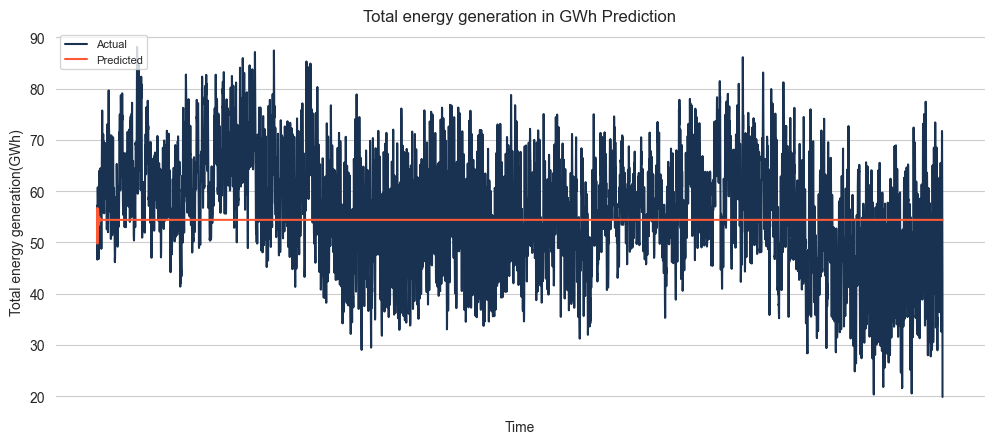

In [109]:
# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
#plt.plot(train_data_0, label='Training')
plt.plot(test_data_0, label='Actual')
plt.plot(fcv_series_a,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))


In [115]:
def plot_ts(ts = None, ts_add = None, title ='Time Series', legend=['1']):
    """
    Plots one or two time series in a single plot
    
        Args:
        ts: 1d- or 2d-array of time series. Dimension
            must be (n,) or (n,2)
        title: Title for the time plot.
        legend: list of legend names. If empty no legend.
        
        Returns:
        matplotlib plot object
    """
    plt.figure(figsize=(10, 4))
    plt.plot(ts[:,], color=NF_ORANGE)
    plt.grid(True,axis='y')
    plt.title(title)
    if ts_add is not None:
        plt.plot(ts_add, color=NF_BLUE)
    if len(legend) > 0:
        plt.legend(legend)
    plt.show()

def plot_acf_pacf(ts, lags=10, layout='h'):
    """
    Plots the empirical ACF and PACF of a time series process.
    
        Args:
        ts: array of time series
        
        Returns:
        matplotlib subplot with ACF and PACF
    """
    if layout == 'h':
        fig, ax = plt.subplots(1, 2, figsize = (10,3))
    else: 
        fig, ax = plt.subplots(2, 1, figsize = (10,3))
    sm.tsa.graphics.plot_acf(ts,color = NF_ORANGE,lags=lags, ax = ax[0])
    sm.tsa.graphics.plot_pacf(ts,color = NF_ORANGE, lags = lags, ax = ax[1])    


def diff_series(ts, interval=1):
    """
    Differences a time series by a certain lag.
    
        Args:
        ts: array of 1d time series
        
        Returns:
        Differenced time series
    """
    diff = ts[interval:] - ts[:-interval]
    return diff

def kpss_test(ts):
    """
    Performs a KPSS test for the null hypothesis of stationarity.
    
        Args:
        ts: 1d time series
        
        Returns:
        Summary of test statistic and critical values
    """
    print ('Results of KPSS Test:')
    kpsstest = kpss(ts, regression='c', nlags='legacy')
    kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic','p-value','Lags Used'])
    for key,value in kpsstest[3].items():
        kpss_output['Critical Value (%s)'%key] = value
    print (kpss_output)

def adf_test(ts):
    """
    Performs a Dickey-Fuller test for the null hypothesis of
    non-stationarity.
    
        Args:
        ts: 1-d time series
    
        Returns:
        Printed test statistic and critical values.
    """
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(ts, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used',
                                             'Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

In-sample RMSE: 13.228959818025128


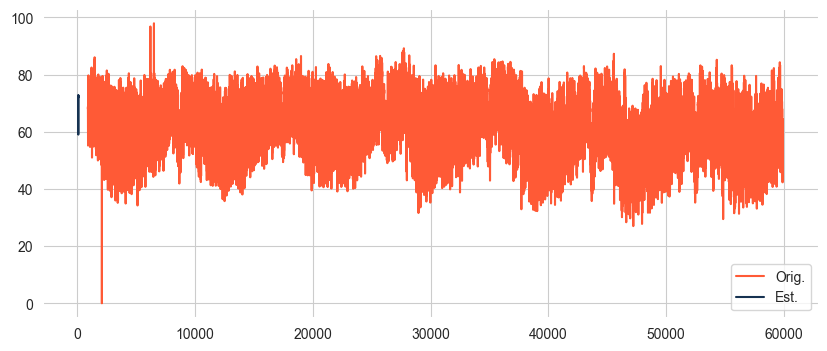

In [117]:
# Use a smoothing level alpha of 0.4, i.e.
# past values will be given a weight of 60%
# actual values a weight of the remaining 40% 
#dfs[target]
simple_exp = SimpleExpSmoothing(train_data_0, initialization_method='estimated').fit(smoothing_level=0.6,optimized=False)

# Predict the last 20 values in the original
# time series
pred = simple_exp.predict(980, 999)
y_pred = np.ndarray((100,))

# Set the points not forecasted to NaN 
# (this does not plot them)
y_pred[:80] = np.NaN 
y_pred[80:] = pred

# Print the forecast RMSE.
print('In-sample RMSE: {}'.format(np.sqrt(np.sum((train_data_0[980:] - pred)**2))))
plot_ts(train_data_0[900:], y_pred, title = '', legend=['Orig.', 'Est.'])

In-sample RMSE: 8.904962567597355


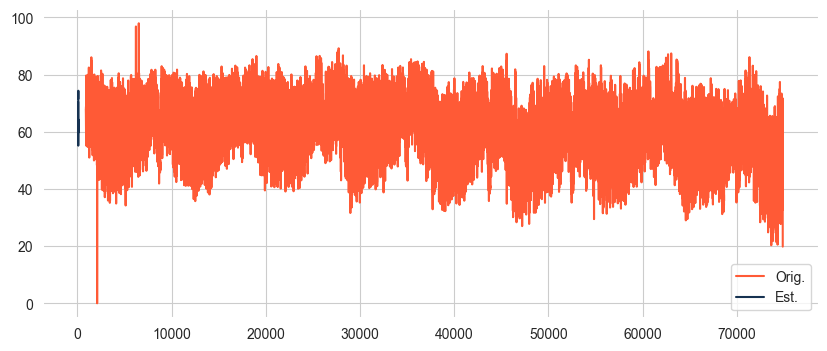

In [118]:
# Use an additive seasonality and additive trend. 
# As we know from prior EDA, we have a cycle of 4. 
y = dfs[target]#train_data_0
holt_winters = ExponentialSmoothing(y, seasonal_periods=4,seasonal='add', trend='add', initialization_method='estimated')
res = holt_winters.fit()

# Make a prediction for the last 20 values. 
pred = res.predict(980, 999)
y_pred = np.ndarray((100,))

# Set the points not forecasted to NaN 
# (this does not plot them)
y_pred[:80] = np.NaN 
y_pred[80:] = pred

# Print the forecast RMSE.
print('In-sample RMSE: {}'.format(np.sqrt(np.sum((y[980:1000] - pred)**2))))
plot_ts(y[900:], y_pred, title = '', legend=['Orig.', 'Est.'])